In [1]:
from tabpfn_project.paths import RESULTS_DIR
from tabpfn_project.helper.utils import load_pickle, fetch_save_dict

In [2]:
tabpfn_dir = RESULTS_DIR / "TabPFN"
distnet_dir = RESULTS_DIR / "DistNet"
random_forest_dir = RESULTS_DIR / "RandomForest"
gp_dir = RESULTS_DIR / "GaussianProcess"

tabpfn_log_results = load_pickle(tabpfn_dir / "tabpfn_results_exp_feature_dropping.pkl")
distnet_max_results = load_pickle(distnet_dir / "distnet_results_exp_feature_dropping_target_scale_max.pkl")
random_forest_results = load_pickle(random_forest_dir / "random_forest_results_exp_feature_dropping.pkl")
gp_results = load_pickle(gp_dir / "gp_results_exp_feature_dropping.pkl")

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import ScalarFormatter

# def plot_feat_dropping_results(results_data, visual_config, log_x=False, log_y=False, 
#                     zoom_on_model=None, mark_best=False, 
#                     plot_scenario=None, plot_metric=None, plot_title=None):
#     """
#     Plots ML experiment results for the 'feature dropping' experiment.
    
#     Aggregation Logic:
#     1. Run-level: Mean of internal instance scores.
#     2. Context-Seed-level: Mean across seed_context_size.
#     3. Drop-Rate-Seed-level: Mean across seed_feature_drop_rate.
#     4. Fold-level: Mean and Std across folds.
#     """
#     # 1. Validation
#     if set(results_data.keys()) != set(visual_config.keys()):
#         raise KeyError("The keys in results_data and visual_config must match exactly.")
    
#     if zoom_on_model is not None and zoom_on_model not in results_data.keys():
#         raise ValueError(f"zoom_on_model '{zoom_on_model}' not found in results_data keys.")

#     # 2. Flatten and Pre-process Data
#     all_records = []
#     metrics_list = []

#     for model_name, runs in results_data.items():
#         for run in runs:
#             scenario = run['scenario']
#             # The x-axis for this experiment
#             n_features_keep = run['n_features_keep'] 
#             fold = run['fold']
#             seed_ctx = run['seed_context_size']
#             seed_drop = run['seed_feature_drop_rate']
#             summary = run['instance_summary']
            
#             for metric_name, values in summary.items():
#                 if metric_name not in metrics_list:
#                     metrics_list.append(metric_name)
                
#                 # Step 1: Compute the average performance per run (Instance Mean)
#                 val = values.numpy().mean() if hasattr(values, 'numpy') else np.mean(values)
#                 all_records.append({
#                     "model": model_name, "scenario": scenario, 
#                     "n_features_keep": n_features_keep, "fold": fold, 
#                     "seed_ctx": seed_ctx, "seed_drop": seed_drop, 
#                     "metric": metric_name, "value": val
#                 })

#     df = pd.DataFrame(all_records)
    
#     # Filtering
#     all_available_scenarios = sorted(df['scenario'].unique())
#     all_available_metrics = metrics_list

#     # Handle Scenario filtering (supports single string or list of strings)
#     if plot_scenario is not None:
#         # Normalize input to a list
#         requested_scenarios = [plot_scenario] if isinstance(plot_scenario, str) else plot_scenario
        
#         # Validate that all requested scenarios exist in the available data
#         missing = set(requested_scenarios) - set(all_available_scenarios)
#         if missing:
#             raise ValueError(f"Scenarios {missing} not found in data. Available: {all_available_scenarios}")
        
#         scenarios = requested_scenarios
#     else:
#         scenarios = all_available_scenarios

#     if plot_metric is not None:
#         if plot_metric not in all_available_metrics:
#             raise ValueError(f"Metric '{plot_metric}' not found in data.")
#         metrics = [plot_metric]
#     else:
#         metrics = all_available_metrics

#     x_ticks = sorted(df['n_features_keep'].unique())

#     # 3. Plotting Setup
#     fig, axes = plt.subplots(len(scenarios), len(metrics), 
#                              figsize=(6 * len(metrics), 5 * len(scenarios)), 
#                              squeeze=False)

#     for row_idx, scenario in enumerate(scenarios):
#         for col_idx, metric in enumerate(metrics):
#             ax = axes[row_idx][col_idx]
            
#             zoom_bounds = {"min": float('inf'), "max": float('-inf')}
#             abs_best_val = float('inf')
#             abs_best_model = None
#             abs_best_coords = (None, None)
#             line_objs = {}
            
#             for model_name, (color, hatch) in visual_config.items():
#                 subset = df[(df['model'] == model_name) & (df['scenario'] == scenario) & (df['metric'] == metric)]
#                 if subset.empty: continue

#                 # --- NESTED AGGREGATION LOGIC ---
#                 # Step 2: Average across all seed_context_size seeds for each (fold, seed_feature_drop_rate)
#                 ctx_agg = subset.groupby(['n_features_keep', 'fold', 'seed_drop'])['value'].mean().reset_index()
                
#                 # Step 3: Average across seed_feature_drop_rate values for each fold
#                 fold_agg = ctx_agg.groupby(['n_features_keep', 'fold'])['value'].mean().reset_index()
                
#                 # Step 4: Aggregate across folds (Mean and Std)
#                 final_stats = fold_agg.groupby('n_features_keep')['value'].agg(['mean', 'std']).reset_index().sort_values('n_features_keep')
                
#                 x = final_stats['n_features_keep']
#                 y_mean = final_stats['mean']
#                 y_std = final_stats['std']
                
#                 line, = ax.plot(x, y_mean, label=model_name, color=color, marker='o', markersize=4)
#                 line_objs[model_name] = line
                
#                 # Conditional Shade Clipping (Prevents Log-Pillars)
#                 lower_bound = y_mean - y_std
#                 upper_bound = y_mean + y_std
#                 if log_y and metric != 'NLLH':
#                     lower_bound = np.maximum(lower_bound, y_mean * 0.1)
                
#                 ax.fill_between(x, lower_bound, upper_bound, color=color, alpha=0.2, hatch=hatch, edgecolor='none')
                
#                 if y_mean.min() < abs_best_val:
#                     abs_best_val = y_mean.min()
#                     abs_best_model = model_name
#                     abs_best_coords = (x[y_mean.idxmin()], abs_best_val)

#                 if zoom_on_model == model_name:
#                     zoom_bounds["min"] = min(zoom_bounds["min"], (y_mean - y_std).min())
#                     zoom_bounds["max"] = max(zoom_bounds["max"], (y_mean + y_std).max())

#             # Mark Best
#             if mark_best and abs_best_model is not None:
#                 bx, by = abs_best_coords
#                 ax.scatter(bx, by, color='gold', marker='*', s=150, edgecolor='black', linewidth=0.5, zorder=5, label='_nolegend_')
#                 line_objs[abs_best_model].set_label(f"{line_objs[abs_best_model].get_label()} <-- Best")

#             # Robust Zoom Logic
#             if zoom_on_model is not None:
#                 margin = (zoom_bounds["max"] - zoom_bounds["min"]) * 0.05
#                 low, high = zoom_bounds["min"] - margin, zoom_bounds["max"] + margin
#                 if log_y and metric != 'NLLH' and low <= 0:
#                     low = zoom_bounds["min"] * 0.9 if zoom_bounds["min"] > 0 else 1e-9
#                 ax.set_ylim(low, high)

#             # Axis Formatting
#             current_x_ticks = sorted(subset['n_features_keep'].unique())

#             if log_x:
#                 ax.set_xscale('symlog', linthresh=1)
#                 ax.xaxis.set_major_formatter(ScalarFormatter())
            
#             # 1. Keep ALL ticks visible
#             ax.set_xticks(current_x_ticks) 
            
#             # 2. Generate labels: Every second value, starting from the LEFT (the max value)
#             # Since the axis is inverted, the leftmost value is the last index of current_x_ticks
#             all_labels = [str(val) for val in current_x_ticks]
#             # We iterate backwards from the end to ensure the leftmost label is always shown
#             filtered_labels = [
#                 all_labels[i] if (len(all_labels) - 1 - i) % 2 == 0 else "" 
#                 for i in range(len(all_labels))
#             ]
#             ax.set_xticklabels(filtered_labels)

#             # 3. Formatting for readability
#             plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=9)
            
#             # 4. Tighten limits and Invert
#             ax.set_xlim(min(current_x_ticks), max(current_x_ticks))
#             ax.invert_xaxis() 
#             if log_y and metric != 'NLLH': ax.set_yscale('log')

#             # Handle Invisible Models (Legend Annotation)
#             if zoom_on_model is not None:
#                 current_ylim_max = ax.get_ylim()[1]
#                 for model_name, line in line_objs.items():
#                     subset = df[(df['model'] == model_name) & (df['scenario'] == scenario) & (df['metric'] == metric)]
#                     if subset.empty: continue
#                     # Use the same aggregation sequence to find if the model is off-chart
#                     ctx_agg = subset.groupby(['n_features_keep', 'fold', 'seed_drop'])['value'].mean().reset_index()
#                     fold_agg = ctx_agg.groupby(['n_features_keep', 'fold'])['value'].mean().reset_index()
#                     stats = fold_agg.groupby('n_features_keep')['value'].agg(['mean', 'std'])
#                     if (stats['mean'] - stats['std']).min() > current_ylim_max:
#                         lbl = line.get_label()
#                         if " <-- Best" not in lbl: line.set_label(f"{lbl} (≫)")

#             # Layout
#             if row_idx == 0: ax.set_title(f"Metric: {metric}", fontsize=14, fontweight='bold')
#             ax.set_ylabel(f"{scenario}\n{metric}" if col_idx == 0 else metric, fontsize=12, fontweight='bold')
#             ax.set_xlabel("Number of Features")
#             ax.grid(True, linestyle='--', alpha=0.6)
#             ax.legend(loc='upper right', fontsize=9)

#     if plot_title:
#         fig.suptitle(plot_title, fontsize=18, fontweight='bold')
#         plt.tight_layout(rect=[0, 0, 1, 0.96]) 
#     else:
#         plt.tight_layout()
    
#     return fig

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


In [5]:
scenarios = [
    "clasp_factoring",
    "saps-CVVAR",
    "spear_qcp",
    "yalsat_qcp",
    "spear_swgcp",
    "yalsat_swgcp",
    "lpg-zeno"
]

metrics = [
    "NLLH",
    "CRPS",
    "Wasserstein",
    "KS"
]

results_dict = {
    "TabPFN": tabpfn_log_results,
    "DistNet":distnet_max_results,
    "Random Forest": random_forest_results,
    "Gaussian Process": gp_results
}

visual_cfg = {
    # --- The Star Model ---
    "TabPFN": ("#2CA02C", "xx"),           # Green
    
    # --- Deep / Advanced Competitors ---
    "DistNet": ("#D62728", "--"),          # Red
    
    # --- Classic ML Competitors ---
    "Gaussian Process": ("#9467BD", ".."), # Purple
    "Random Forest": ("#FF7F0E", "\\"),    # Orange
}

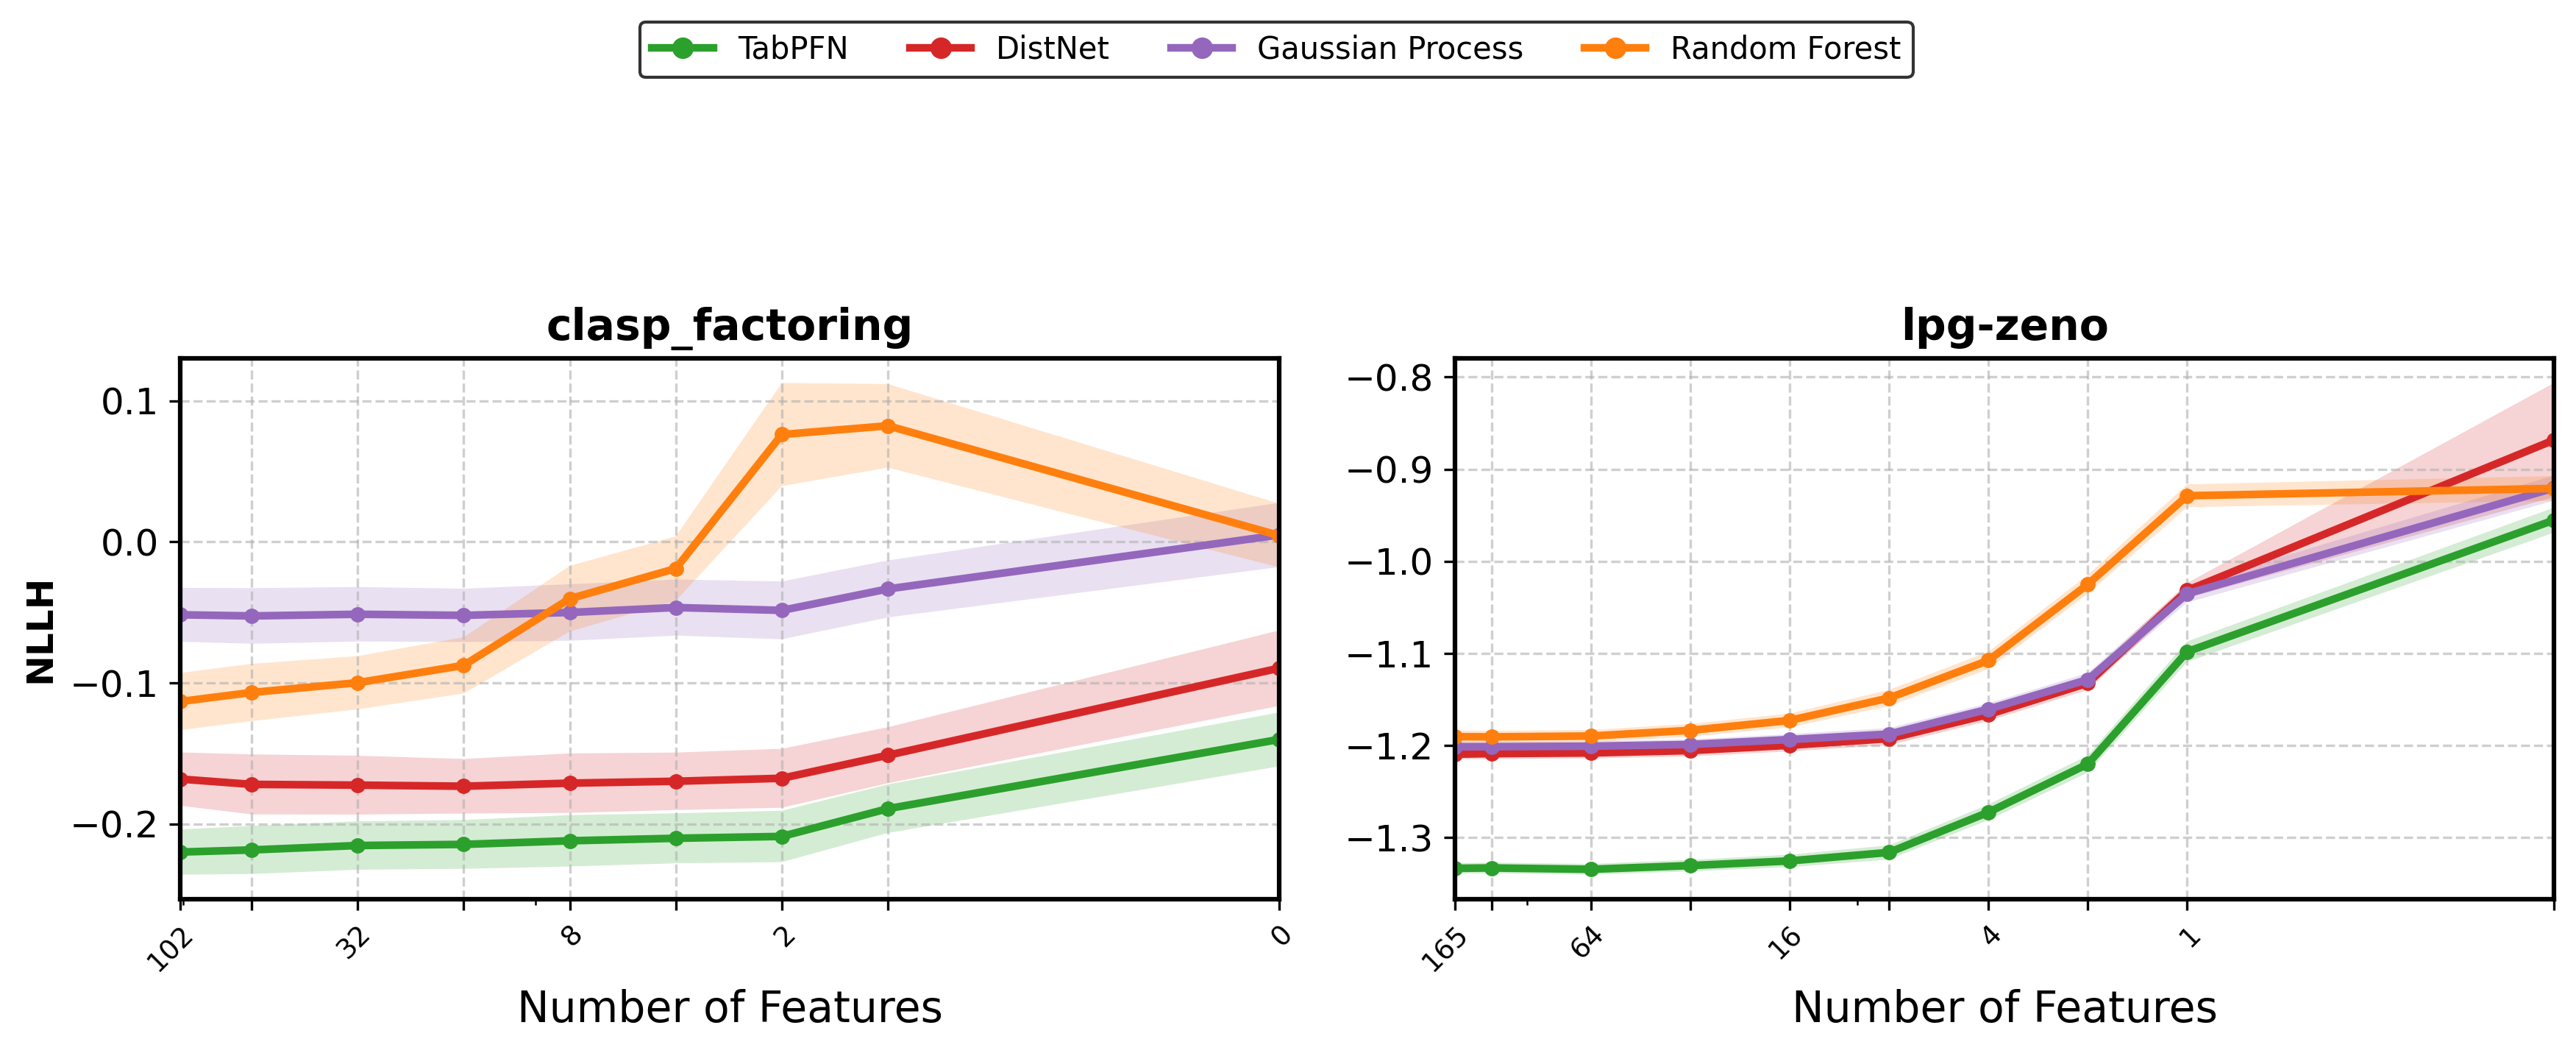

In [6]:
from tabpfn_project.helper.utils import plot_feat_dropping_results


fig = plot_feat_dropping_results(results_dict, visual_cfg, log_x=True, log_y=True, zoom_on_model=None, plot_scenario=["clasp_factoring", "lpg-zeno"], plot_metric="NLLH", grid_layout=(-1,2))
fig.savefig("fdrop_c1200.png", format="png", dpi=1200, bbox_inches="tight") 
